In [1]:
import numpy as np
import pandas as pd

In [68]:
!pip install -q "kagglehub[pandas-datasets]"

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "spam.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/sms-spam-collection-dataset",
    file_path,
    pandas_kwargs={
        "encoding": "latin-1"
    }
)

print("First 5 records:")
display(df.sample(5))


First 5 records:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3825,ham,"Goodmorning,my grandfather expired..so am on l...",NaN,NaN,NaN
59,ham,Yes..gauti and sehwag out of odi series.,NaN,NaN,NaN
336,ham,Cool. So how come you havent been wined and di...,NaN,NaN,NaN
5349,ham,I'm home...,NaN,NaN,NaN
263,spam,Hey I am really horny want to chat or see me n...,NaN,NaN,NaN


## Remove unnecesary columns

In [3]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unname

In [4]:
df=df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])
df.head(5)


df.rename(columns={
    'v1': 'label',
    'v2': 'message'
}, inplace=True)

print(df.head())
print(df.columns)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='object')


In [5]:
df.rename(columns={
    'v1': 'label',
    'v2': 'message'
}, inplace=True)

print(df.head())
print(df.columns)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='object')


## check data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
df.shape

(5572, 2)

In [8]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

## Normalize the sms

In [13]:
df['message'] = df['message'].str.lower()

<Axes: xlabel='label', ylabel='count'>

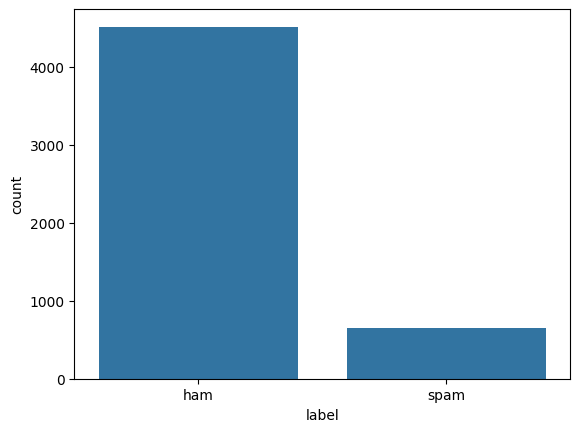

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(df,x='label')

In [15]:
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True) * 100)

label
ham     4516
spam     653
Name: count, dtype: int64

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


## convert labels into 1 and 0

In [16]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

In [17]:
df.head()

,label,message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [18]:
encoder.classes_

array(['ham', 'spam'], dtype=object)

## Train_test_split

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,1],df.iloc[:,0],test_size=0.2,random_state=42,
    stratify=df.iloc[:, 0])

In [25]:
X_train

336     cool. so how come you havent been wined and di...
390                             huh so late... fr dinner?
583     my ex-wife was not able to have kids. do you w...
1387    hope ur head doesn't hurt 2 much ! am ploughin...
1095                              ryder unsold.now gibbs.
                              ...                        
606     xclusive@clubsaisai 2morow 28/5 soiree special...
105     thanks a lot for your wishes on my birthday. t...
3789    i love you !!! you know? can you feel it? does...
1911    lol grr my mom is taking forever with my presc...
3742    nah, wednesday. when should i bring the mini c...
Name: message, Length: 4135, dtype: object

In [26]:
y_train

336     0
390     0
583     0
1387    0
1095    0
       ..
606     1
105     0
3789    0
1911    0
3742    0
Name: label, Length: 4135, dtype: int64

## reomve punctuations

In [27]:
import re

def remove_punctuation(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [28]:
text = "Congratulations!!! You won £1000. Call NOW!!!"

print(remove_punctuation(text))

Congratulations You won 1000 Call NOW


## Tokenization

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [30]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 7591)
Testing shape: (1034, 7591)


In [31]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[1000:1050])

Number of features: 7591
['apartment' 'apes' 'apeshit' 'aphexåõs' 'apnt' 'apo' 'apologetic'
 'apologise' 'apology' 'app' 'apparently' 'appeal' 'appendix'
 'applausestore' 'applebees' 'apples' 'application' 'apply' 'applyed'
 'applying' 'appointment' 'appreciate' 'appreciated' 'approaches'
 'approaching' 'approved' 'approx' 'apps' 'appt' 'appy' 'april' 'aproach'
 'apt' 'aptitude' 'aquarius' 'ar' 'arabian' 'arcade' 'archive' 'ard' 'are'
 'area' 'aren' 'aretaking' 'areyouunique' 'argentina' 'argh' 'argue'
 'arguing' 'argument']


## Model Building

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [34]:
y_pred = model.predict(X_test_tfidf)

print("Predicted:", y_pred[:20])
print("Actual:   ", y_test.iloc[:20].values)

Predicted: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [35]:
print("Predicted distribution:")
print(pd.Series(y_pred).value_counts())

print("\nActual distribution:")
print(y_test.value_counts())

Predicted distribution:
0    935
1     99
Name: count, dtype: int64

Actual distribution:
label
0    903
1    131
Name: count, dtype: int64


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[902   1]
 [ 33  98]]


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9671179883945842
Precision: 0.98989898989899
Recall   : 0.7480916030534351
F1 Score : 0.8521739130434782


## Porter Stemming

In [38]:
!pip install nltk

In [39]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [40]:
def stem_text(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

In [41]:
text = "Congratulations!!! you are winning prizes"

print("Original :", text)
print("Stemmed  :", stem_text(text))

Original : Congratulations!!! you are winning prizes
Stemmed  : congratulations!!! you are win prize


In [42]:
import re
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def preprocess_stem(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    stemmed_words = [stemmer.stem(word) for word in words]

    return " ".join(stemmed_words)

In [43]:
text = "Congratulations!!! You are winning prizes."

print("Original :", text)
print("Processed:", preprocess_stem(text))

Original : Congratulations!!! You are winning prizes.
Processed: congratul you are win prize


In [44]:
X_train_stem = X_train.apply(preprocess_stem)
X_test_stem = X_test.apply(preprocess_stem)

In [45]:
print("Original:")
print(X_train.iloc[0])

print("\nStemmed:")
print(X_train_stem.iloc[0])

Original:
cool. so how come you havent been wined and dined before?

Stemmed:
cool so how come you havent been wine and dine befor


## Exp 1: Stemming and tdidf

In [46]:
tfidf_stem = TfidfVectorizer()

X_train_stem_tfidf = tfidf_stem.fit_transform(X_train_stem)
X_test_stem_tfidf = tfidf_stem.transform(X_test_stem)

In [47]:
print("Training shape:", X_train_stem_tfidf.shape)
print("Testing shape:", X_test_stem_tfidf.shape)

Training shape: (4135, 7076)
Testing shape: (1034, 7076)


In [48]:
model_stem=LogisticRegression()
model_stem.fit(X_train_stem_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [49]:
y_pred_stem = model_stem.predict(X_test_stem_tfidf)

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_stem))
print("Precision:", precision_score(y_test, y_pred_stem))
print("Recall   :", recall_score(y_test, y_pred_stem))
print("F1 Score :", f1_score(y_test, y_pred_stem))

Accuracy : 0.9680851063829787
Precision: 0.99
Recall   : 0.7557251908396947
F1 Score : 0.8571428571428571


In [51]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_stem))

[[902   1]
 [ 32  99]]


In [52]:
results = {
    "Baseline": {
        "Accuracy": 0.9671,
        "Precision": 0.9899,
        "Recall": 0.7481,
        "F1": 0.8522
    },
    "Porter Stemming": {
        "Accuracy": 0.9681,
        "Precision": 0.9900,
        "Recall": 0.7557,
        "F1": 0.8571
    }
}

## stopword removal

In [53]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]
    
    return " ".join(filtered_words)

text = "I am going to the market"

print("Original :", text)
print("Processed:", remove_stopwords(text))

Original : I am going to the market
Processed: I going market


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/saikeshav/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [54]:
X_train_stop = X_train.apply(remove_stopwords)
X_test_stop = X_test.apply(remove_stopwords)

In [55]:
tfidf_stop = TfidfVectorizer()

X_train_stop_tfidf = tfidf_stop.fit_transform(X_train_stop)
X_test_stop_tfidf = tfidf_stop.transform(X_test_stop)

In [56]:
print("Training shape:", X_train_stop_tfidf.shape)
print("Testing shape:", X_test_stop_tfidf.shape)

Training shape: (4135, 7569)
Testing shape: (1034, 7569)


In [57]:
model_stop = LogisticRegression()

model_stop.fit(X_train_stop_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [58]:
y_pred_stop = model_stop.predict(X_test_stop_tfidf)

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_stop))
print("Precision:", precision_score(y_test, y_pred_stop))
print("Recall   :", recall_score(y_test, y_pred_stop))
print("F1 Score :", f1_score(y_test, y_pred_stop))

Accuracy : 0.9613152804642167
Precision: 0.9789473684210527
Recall   : 0.7099236641221374
F1 Score : 0.8230088495575221


In [60]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_stop))

[[901   2]
 [ 38  93]]


## Snowball Stemmer

In [61]:
from nltk.stem import SnowballStemmer

snowball = SnowballStemmer("english")

In [62]:
def preprocess_snowball(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    stemmed_words = [snowball.stem(word) for word in words]

    return " ".join(stemmed_words)

In [63]:
text = "Congratulations you are winning prizes"

print("Original :", text)
print("Porter   :", preprocess_stem(text))
print("Snowball :", preprocess_snowball(text))

Original : Congratulations you are winning prizes
Porter   : congratul you are win prize
Snowball : congratul you are win prize


In [64]:
words = [
    "generously",
    "relational",
    "studies",
    "running",
    "easily",
    "fairly",
    "organization",
    "traditional"
]

for word in words:
    print(f"{word:15} Porter: {stemmer.stem(word):15} Snowball: {snowball.stem(word)}")

generously      Porter: gener           Snowball: generous
relational      Porter: relat           Snowball: relat
studies         Porter: studi           Snowball: studi
running         Porter: run             Snowball: run
easily          Porter: easili          Snowball: easili
fairly          Porter: fairli          Snowball: fair
organization    Porter: organ           Snowball: organ
traditional     Porter: tradit          Snowball: tradit


In [65]:
X_train_snowball = X_train.apply(preprocess_snowball)
X_test_snowball = X_test.apply(preprocess_snowball)

In [66]:
print("Original:")
print(X_train.iloc[0])

print("\nSnowball:")
print(X_train_snowball.iloc[0])

Original:
cool. so how come you havent been wined and dined before?

Snowball:
cool so how come you havent been wine and dine befor


In [67]:
tfidf_snowball = TfidfVectorizer()

X_train_snowball_tfidf = tfidf_snowball.fit_transform(X_train_snowball)
X_test_snowball_tfidf = tfidf_snowball.transform(X_test_snowball)

In [68]:
print("Training shape:", X_train_snowball_tfidf.shape)
print("Testing shape:", X_test_snowball_tfidf.shape)

Training shape: (4135, 7083)
Testing shape: (1034, 7083)


In [69]:
model_snowball = LogisticRegression()

model_snowball.fit(X_train_snowball_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [70]:
y_pred_snowball = model_snowball.predict(X_test_snowball_tfidf)

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_snowball))
print("Precision:", precision_score(y_test, y_pred_snowball))
print("Recall   :", recall_score(y_test, y_pred_snowball))
print("F1 Score :", f1_score(y_test, y_pred_snowball))

Accuracy : 0.9680851063829787
Precision: 0.99
Recall   : 0.7557251908396947
F1 Score : 0.8571428571428571


In [72]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_snowball))

[[902   1]
 [ 32  99]]


## multimodal Naive's Bayes

In [73]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train_stem_tfidf, y_train)

y_pred_nb = model_nb.predict(X_test_stem_tfidf)

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Accuracy : 0.9497098646034816
Precision: 1.0
Recall   : 0.6030534351145038
F1 Score : 0.7523809523809524


In [75]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_nb))

[[903   0]
 [ 52  79]]


## LinearSVzc

In [76]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()

model_svm.fit(X_train_stem_tfidf, y_train)

y_pred_svm = model_svm.predict(X_test_stem_tfidf)

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.9825918762088974
Precision: 0.9747899159663865
Recall   : 0.8854961832061069
F1 Score : 0.928


In [78]:
print(confusion_matrix(y_test, y_pred_svm))

[[900   3]
 [ 15 116]]


In [79]:
results["Linear SVM + Porter"] = {
    "Accuracy": 0.9826,
    "Precision": 0.9748,
    "Recall": 0.8855,
    "F1": 0.9280
}

In [80]:
results

{'Baseline': {'Accuracy': 0.9671,
  'Precision': 0.9899,
  'Recall': 0.7481,
  'F1': 0.8522},
 'Porter Stemming': {'Accuracy': 0.9681,
  'Precision': 0.99,
  'Recall': 0.7557,
  'F1': 0.8571},
 'Linear SVM + Porter': {'Accuracy': 0.9826,
  'Precision': 0.9748,
  'Recall': 0.8855,
  'F1': 0.928}}

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_ngram = TfidfVectorizer(ngram_range=(1, 2))

X_train_ngram = tfidf_ngram.fit_transform(X_train_stem)
X_test_ngram = tfidf_ngram.transform(X_test_stem)

print("Training shape:", X_train_ngram.shape)
print("Testing shape:", X_test_ngram.shape)

Training shape: (4135, 40419)
Testing shape: (1034, 40419)


In [82]:
from sklearn.svm import LinearSVC

model_svm_ngram = LinearSVC()
model_svm_ngram.fit(X_train_ngram, y_train)

y_pred_svm_ngram = model_svm_ngram.predict(X_test_ngram)

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_svm_ngram))
print("Precision:", precision_score(y_test, y_pred_svm_ngram))
print("Recall   :", recall_score(y_test, y_pred_svm_ngram))
print("F1 Score :", f1_score(y_test, y_pred_svm_ngram))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_ngram))

Accuracy : 0.9835589941972921
Precision: 0.9830508474576272
Recall   : 0.8854961832061069
F1 Score : 0.9317269076305221

Confusion Matrix:
[[901   2]
 [ 15 116]]


## trigram

In [84]:
tfidf_trigram = TfidfVectorizer(ngram_range=(1, 3))

X_train_trigram = tfidf_trigram.fit_transform(X_train_stem)
X_test_trigram = tfidf_trigram.transform(X_test_stem)

print("Training shape:", X_train_trigram.shape)
print("Testing shape:", X_test_trigram.shape)

Training shape: (4135, 83403)
Testing shape: (1034, 83403)


In [85]:
tfidf_trigram = TfidfVectorizer(ngram_range=(1, 3))

X_train_trigram = tfidf_trigram.fit_transform(X_train_stem)
X_test_trigram = tfidf_trigram.transform(X_test_stem)

print("Training shape:", X_train_trigram.shape)
print("Testing shape:", X_test_trigram.shape)

Training shape: (4135, 83403)
Testing shape: (1034, 83403)


In [86]:
model_svm_trigram = LinearSVC()
model_svm_trigram.fit(X_train_trigram, y_train)

y_pred_svm_trigram = model_svm_trigram.predict(X_test_trigram)

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_svm_trigram))
print("Precision:", precision_score(y_test, y_pred_svm_trigram))
print("Recall   :", recall_score(y_test, y_pred_svm_trigram))
print("F1 Score :", f1_score(y_test, y_pred_svm_trigram))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_trigram))

Accuracy : 0.9835589941972921
Precision: 0.9830508474576272
Recall   : 0.8854961832061069
F1 Score : 0.9317269076305221

Confusion Matrix:
[[901   2]
 [ 15 116]]


## stratified cv

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("svm", LinearSVC())
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    pipeline,
    X_train_stem,
    y_train,
    cv=cv,
    scoring="f1"
)

print("F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())

F1 scores: [0.89583333 0.93401015 0.91176471 0.93596059 0.91457286]
Mean F1: 0.9184283293909127
Std F1: 0.014966467468841674


## Final

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

final_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("svm", LinearSVC())
])

print(final_model)

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('svm', LinearSVC())])


In [91]:
final_model.fit(X_train_stem, y_train)

print("Final model trained successfully.")

Final model trained successfully.


In [92]:
y_pred_final = final_model.predict(X_test_stem)

print("Final predictions generated successfully.")

Final predictions generated successfully.


In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=["Ham", "Spam"]))

Accuracy : 0.9835589941972921
Precision: 0.9830508474576272
Recall   : 0.8854961832061069
F1 Score : 0.9317269076305221

Confusion Matrix:
[[901   2]
 [ 15 116]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.98      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [ ]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))